In [2]:
import EFC_learningfMRI.globals as gl
import os
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
import numpy as np
import nitools as nt
from EFC_learningfMRI.vis import plot_im_sess, custom_legend
from imaging_pipelines.vis import plot_surf
import PcmPy as pcm
from EFC_learningfMRI.G_matrix import G_sorted
from EFC_learningfMRI.util import get_trained_and_untrained
from EFC_learningfMRI.pcm import make_models
from matplotlib.colors import LinearSegmentedColormap, Normalize
import pingouin as pg
import statsmodels.formula.api as smf
import itertools
import nibabel as nb
import warnings

warnings.filterwarnings('ignore')

base directory found: /cifs/diedrichsen/data/Chord_exp/EFC_learningfMRI
Atlas directory found: atlases
figure directory found: figures/


In [3]:
H     = 'L'
atlas = 'ROI'
rois  = gl.rois[atlas]
glm   = 3
sns   = gl.participants
sn    = 108

# Representational geometry at session 3
*Compare with model components below

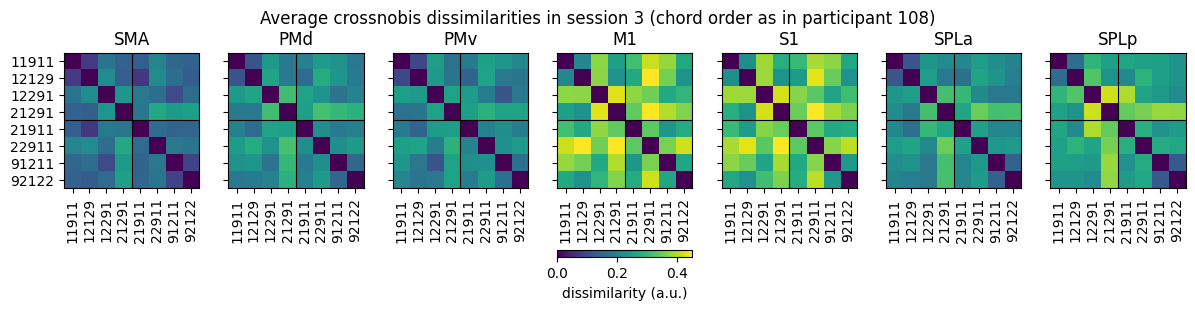

In [4]:
fig, axs = plt.subplots(1, len(rois), sharex=True, sharey=True, constrained_layout=True, figsize=(12, 3))

vmin, vmax = 0, .45

for r, roi in enumerate(rois):
    G  = []
    for s in sns:
        G.append(np.load(os.path.join(gl.baseDir, gl.pcmDir, f'subj{s}', f'G_obs.within_session.3.glm{glm}.{H}.{roi}.npy')))
    G  = np.array(G)

    ax = axs[r]
    G_sort  = G_sorted(G, sns, order=get_trained_and_untrained(sn))
    D  = pcm.G_to_dist(G_sort)
    D  = np.sign(D) * np.sqrt(np.abs(D))
    im = ax.imshow(D.mean(axis=0), vmin=vmin, vmax=vmax)
    ax.axhline(3.5, lw=.8, color='k')
    ax.axvline(3.5, lw=.8, color='k')
    ax.set_xticks(np.arange(8))
    ax.set_yticks(np.arange(8))
    ax.set_xticklabels(gl.chordID, rotation=90)
    ax.set_yticklabels(gl.chordID)
    ax.set_title(roi)

fig.colorbar(im, ax=axs, fraction=.05, label='dissimilarity (a.u.)', orientation='horizontal')

fig.suptitle(f'Average crossnobis dissimilarities in session 3 (chord order as in participant {sn})')

plt.show()

# Crossnobis dissimilarities across sessions
In M1 and S1, activity patterns for trained chords are more distant among each other compared to untrained chords.

           T  dof     p_val           CI95   roi  session
0  -0.670652   12  0.515143  [-0.02, 0.01]   SMA        3
1  -0.314217   12  0.758752  [-0.03, 0.02]   SMA        9
2  -0.655332   12  0.524619  [-0.02, 0.01]   SMA       23
3  -0.390954   12  0.702684  [-0.02, 0.01]   PMd        3
4  -0.624896   12  0.543739  [-0.04, 0.02]   PMd        9
5   0.409752   12  0.689208  [-0.01, 0.02]   PMd       23
6  -1.568458   12  0.142753  [-0.04, 0.01]   PMv        3
7  -0.379392   12  0.711025  [-0.04, 0.03]   PMv        9
8  -1.853067   12  0.088612   [-0.02, 0.0]   PMv       23
9  -0.280874   12  0.783591  [-0.05, 0.04]    M1        3
10  0.623455   12  0.544654  [-0.03, 0.06]    M1        9
11  1.870126   12  0.086050  [-0.01, 0.07]    M1       23
12 -0.570027   12  0.579176  [-0.04, 0.02]    S1        3
13  0.769318   12  0.456581  [-0.03, 0.06]    S1        9
14  2.851351   12  0.014586   [0.01, 0.05]    S1       23
15 -1.032929   12  0.322006  [-0.05, 0.02]  SPLa        3
16 -0.232728  

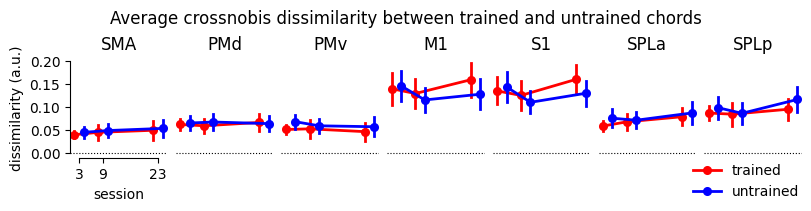

In [5]:
dist            = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, f'dissimilarity.within_session.ROI.glm{glm}.tsv'), sep='\t')
dist            = dist[(dist.Hem=='L') & (dist.chord.isin(['trained', 'untrained']))]
dist_chord_sess = dist.groupby(['sn', 'Hem', 'roi', 'session', 'chord']).mean(numeric_only=True).reset_index()

hue_order = ['trained', 'untrained']
palette   = ['red', 'blue']

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(8, 2), constrained_layout=True)

#plot_im_sess(fig, axs, diss_within, rois, y='dist', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='box', legend=False, alpha=.3)
plot_im_sess(fig, axs, dist_chord_sess, rois, y='crossnobis', x='session', hue='chord', hue_order=hue_order, palette=palette, kind='point', estimator='mean', dodge=.4, add_zero=True)
sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('dissimilarity (a.u.)')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right')
axs[0].set_xlabel('session')

fig.suptitle('Average crossnobis dissimilarity between trained and untrained chords')

ttest_list = []
for roi in rois:
    for session in gl.sessions:
        d   = dist_chord_sess[(dist_chord_sess.roi==roi) & (dist_chord_sess.session==session)]
        piv = d.pivot(index='sn', columns='chord', values='crossnobis')
        ttest_list.append(pg.ttest(piv['trained'], piv['untrained'], paired=True).assign(roi=roi, session=session))
ttest = pd.concat(ttest_list, ignore_index=True)

print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

fig.savefig('figures/crossnobis_mean.pdf')

plt.show()

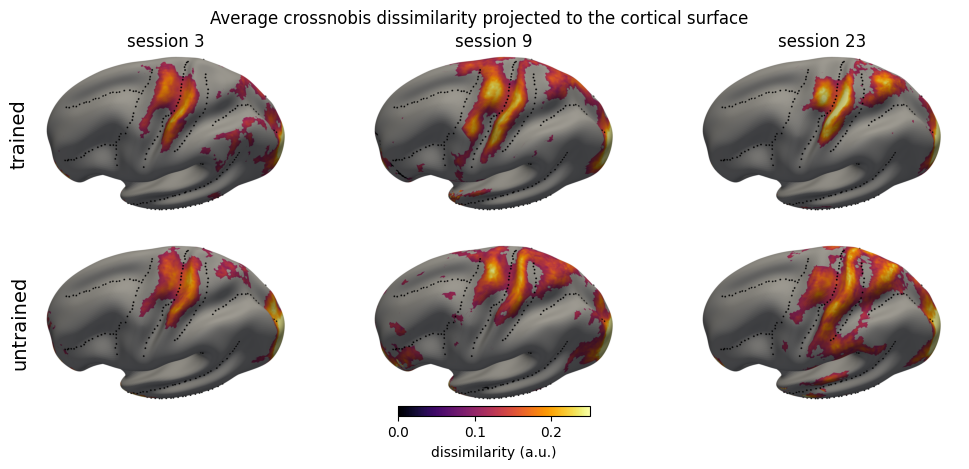

In [6]:
thresh = .1
vmin, vmax = 0, .25
H = 'L'

fig, axs = plt.subplots(2, 3, sharex=True, sharey=True, figsize=(12, 4.5), )

cmap = 'inferno'

for s, session in enumerate(gl.sessions):
    ax       = axs[:, s]
    gifti    = nb.load(os.path.join(gl.baseDir, gl.surfDir, f'searchlight_crossnobis.{session}.glm{glm}.{H}.func.gii'))
    cols     = nt.get_gifti_column_names(gifti)
    tr_col   = cols.index('encoding-trained')
    untr_col = cols.index('encoding-untrained')
    plot_surf(fig, ax[0], gifti, H, cmap=cmap, col=tr_col, thresh=thresh, vmin=vmin, vmax=vmax)
    plot_surf(fig, ax[1], gifti, H, cmap=cmap, col=untr_col, thresh=thresh, vmin=vmin, vmax=vmax)
    ax[0].set_title(f'session {session}')

sm  = plt.cm.ScalarMappable(norm=Normalize(vmin=vmin, vmax=vmax), cmap=cmap)
cax = axs[1, 1].inset_axes([.15, -.10, .7, .06])          # x0, y0, w, h in axes fractions
fig.colorbar(sm, cax=cax, orientation='horizontal', label='dissimilarity (a.u.)')

axs[0, 0].text(0, .5, 'trained', transform=axs[0, 0].transAxes, rotation=90, ha='right', va='center', fontsize=14)
axs[1, 0].text(0, .5, 'untrained', transform=axs[1, 0].transAxes, rotation=90, ha='right', va='center', fontsize=14)

fig.suptitle('Average crossnobis dissimilarity projected to the cortical surface')

fig.savefig('figures/crossnobis_searchlight.pdf')

plt.show()

# Component model

Components and corresponding hypothesis about representational geometry

- **type**     : trained vs. untrained, geometry reflects which chords are practiced
- **trained**  : trained chords are equally distant among each other, no distance between untrained (larger weight -> more pattern separation among *trained* chords)
- **untrained**: untrained chords are equally distant among each other, no distance between untrained (larger weight -> more pattern separation among *untrained* chords)
- **finger**   : geometry reflects which fingers are used in each chord
- **pattern**  : geometry reflects which fingers are used in each chord, and in what direction (i.e., flexion or extension)
- **flexion**  : geometry reflects how many fingers in each chord are pressed in flexion direction

*The **finger**, **pattern** and **flexion** components are different in each participant, depending on the assigned trained and untrained chords 

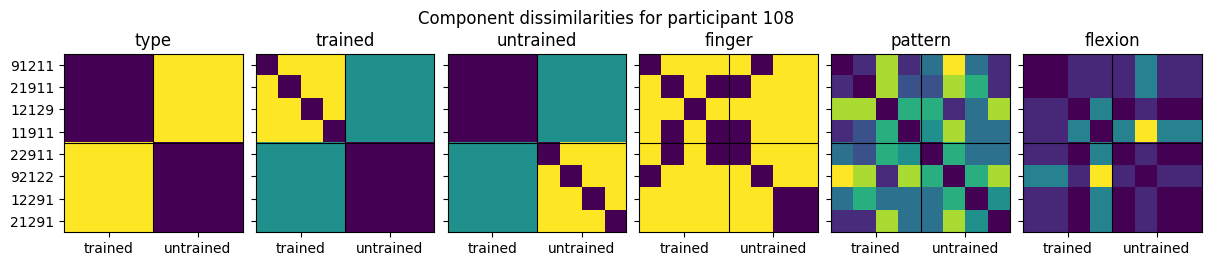

In [7]:
M, comp_names = make_models(sn)
Mc = M[-2]

trained_untrained = get_trained_and_untrained(sn)

fig, axs = plt.subplots(1, Mc.Gc.shape[0], sharex=True, sharey=True, figsize=(12, 2.5), constrained_layout=True)

for i, G in enumerate(Mc.Gc):
    ax = axs[i]
    d = pcm.G_to_dist(G)
    ax.imshow(d)
    ax.axhline(3.5, lw=.8, color='k')
    ax.axvline(3.5, lw=.8, color='k')
    ax.set_xticks([1.5, 5.5])
    ax.set_xticklabels(['trained', 'untrained'])
    ax.set_yticks(np.arange(8))
    ax.set_yticklabels(trained_untrained)
    ax.set_title(comp_names[i])

fig.suptitle(f'Component dissimilarities for participant {sn}')

fig.savefig('figures/components.pdf')

plt.show()

           T  dof     p_val           CI95   roi  session
0  -1.371257   12  0.195393  [-0.03, 0.01]   SMA        3
1  -1.392025   12  0.189176  [-0.05, 0.01]   SMA        9
2  -0.155137   12  0.879292  [-0.02, 0.02]   SMA       23
3  -0.280550   12  0.783834  [-0.03, 0.02]   PMd        3
4  -1.225133   12  0.244029  [-0.07, 0.02]   PMd        9
5   0.600948   12  0.559055  [-0.02, 0.03]   PMd       23
6  -0.118773   12  0.907420  [-0.03, 0.02]   PMv        3
7  -0.991611   12  0.340962  [-0.07, 0.03]   PMv        9
8  -0.721827   12  0.484229  [-0.03, 0.01]   PMv       23
9  -1.040122   12  0.318787  [-0.09, 0.03]    M1        3
10 -0.025873   12  0.979784  [-0.05, 0.05]    M1        9
11  1.865865   12  0.086683   [-0.01, 0.1]    M1       23
12 -0.449319   12  0.661209  [-0.05, 0.03]    S1        3
13 -0.047803   12  0.962660  [-0.04, 0.04]    S1        9
14  2.345231   12  0.037032    [0.0, 0.08]    S1       23
15 -0.882703   12  0.394736  [-0.06, 0.02]  SPLa        3
16 -1.221355  

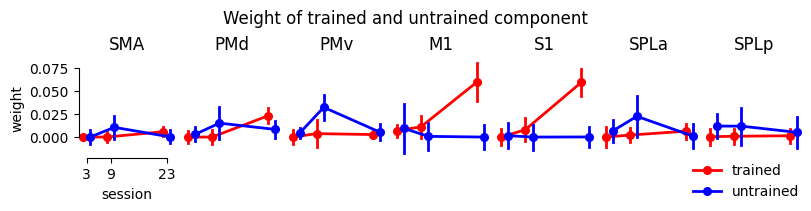

In [8]:
comp_model = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, f'component_model.{atlas}.glm{glm}.tsv'), sep='\t')
N = comp_model.sn.nunique()
hue_order, palette = (['trained', 'untrained'], ['red', 'blue'])
comp_model_tr_untr = comp_model[comp_model.component.isin(hue_order) & (comp_model.Hem==H)]

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(8, 2), constrained_layout=True)

plot_im_sess(fig, axs, comp_model_tr_untr, rois, y='weight', x='session', hue='component', hue_order=hue_order, palette=palette, kind='point', estimator='median', dodge=.3)

sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('weight')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right')
axs[0].set_xlabel('session')

fig.suptitle('Weight of trained and untrained component')

ttest_list = []
for roi in rois:
    for session in gl.sessions:
        d   = comp_model_tr_untr[(comp_model_tr_untr.roi==roi) & (comp_model_tr_untr.session==session)]
        piv = d.pivot(index='sn', columns='component', values='weight')
        ttest_list.append(pg.ttest(piv['trained'], piv['untrained'], paired=True).assign(roi=roi, session=session))
ttest = pd.concat(ttest_list, ignore_index=True)

print(ttest[['T', 'dof', 'p_val', 'CI95', 'roi', 'session']])

fig.savefig('figures/component_model_trained_untrained.pdf')

plt.show()

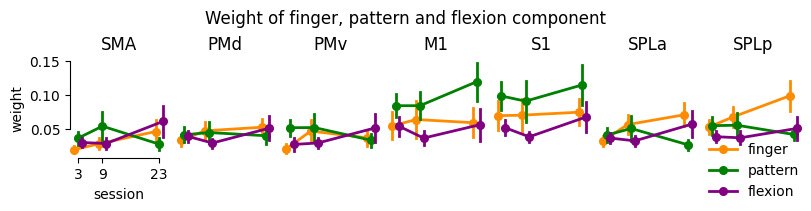

In [9]:
hue_order, palette = ['finger', 'pattern', 'flexion', ], ['darkorange', 'green', 'purple',]
comp_model_repr = comp_model[comp_model.component.isin(hue_order)]

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(8, 2), constrained_layout=True)

plot_im_sess(fig, axs, comp_model_repr, rois, y='weight', x='session', hue='component', hue_order=hue_order, palette=palette, kind='point', dodge=.3, estimator='mean')
#plot_im_sess(fig, axs, comp_model_repr, rois, y='weight_norm', x='session', hue='component', hue_order=hue_order, palette=palette, kind='strip', jitter=.2, alpha=.2)

sb.despine(ax=axs[0], trim=True)
axs[0].set_ylabel('weight')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right')
axs[0].set_xlabel('session')

fig.suptitle('Weight of finger, pattern and flexion component')

fig.savefig('figures/component_model_pattern_flexion.pdf')

plt.show()

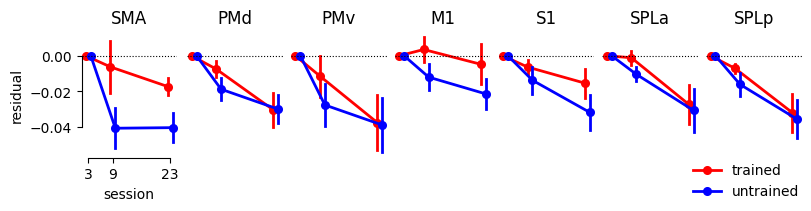

In [10]:
scaling = pd.read_csv(os.path.join(gl.baseDir, gl.pcmDir, f'scaling.between_session.glm{glm}.{atlas}.tsv'), sep='\t')
scaling = scaling[scaling.Hem==H]

fig, axs = plt.subplots(1, len(rois), sharey=True, sharex=True, figsize=(8, 2), constrained_layout=True)

plot_im_sess(fig, axs, scaling, rois=rois, roi_col='roi', y='residual', hue='chord', hue_order=['trained', 'untrained'], palette=['red', 'blue'], estimator='mean', add_zero=True)
#plot_im_sess(fig, axs, scaling, rois=rois, roi_col='roi', y='residual', hue='chord', hue_order=['trained', 'untrained'], palette=['red', 'blue'], kind='strip', legend = False)
sb.despine(ax=axs[0], trim=True)
# axs[0].set_ylabel('theta (rad)')
axs[-1].legend([], frameon=False, loc='upper right')
fig.legend(frameon=False, loc='lower right',)
axs[0].set_xlabel('session')
# fig.suptitle(f'Slope between repetition 1 and 2 (N={N})')
plt.show()